# Problems to solve
• Find the most profitable products/categories

• Identify the best-performing region

• Find products with high sales but low profit

### Setup and loading data

In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
path = kagglehub.dataset_download("vivek468/superstore-dataset-final",output_dir = "/content/superstore")
print("Dataset Path:",path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Dataset Path: /kaggle/input/superstore-dataset-final


In [3]:
import os
os.listdir("/content/superstore")

['Sample - Superstore.csv', '.complete']

In [4]:
import matplotlib.pyplot as plt #to draw plots

In [5]:
from google.colab import files #to download plots.

In [6]:
import pandas as pd
df = pd.read_csv("/content/superstore/Sample - Superstore.csv",encoding = "latin-1")

#### Data exploration

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Most Profitable Categories

In [13]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending = False).head(5)
category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


Technology is highest profitable category.

In [14]:
#Most profitable products
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending = False).head(5)
product_profit

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766


Canon imageCLASS 2200 Advanced Copier is highest profitable product

# identify the best performing region

In [15]:
region = df.groupby('Region')[['Sales','Quantity','Profit']].sum()

In [16]:
cv = region.std() / region.mean()
cv.sort_values(ascending = False)

,0
Profit,0.469306
Quantity,0.274370
Sales,0.270572


The coefficient of variation (CV) was calculated to compare the relative variation of Sales, Quantity, and Profit across regions. Profit had the highest CV, indicating greater relative variation across regions.

In [17]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending = False)
region_profit.head(1)

,Profit
Region,
West,108418.4489


The West region is the best performing region based on total profit. Profit also has the highest coefficient of variation among Sales, Quantity, and Profit,indicating that profit differs relatively more across regions than the other two metrics

# Find products with high sales but low profit

In [18]:
product = df.groupby('Product Name').agg({"Sales":"sum","Profit": "sum","Discount": "mean"})
product["Profit Margin %"] = (product["Profit"]/ product["Sales"]*100).round(2)
product.sort_values('Sales', ascending=False).head(5)

,Sales,Profit,Discount,Profit Margin %
Product Name,,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,0.12,40.91
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,0.24,28.24
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,0.50,-8.00
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,0.20,0.00
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,0.30,11.27


In [19]:

negative_margin = product[product['Profit Margin %'] < 0].sort_values('Profit Margin %').head(10)

negative_margin

,Sales,Profit,Discount,Profit Margin %
Product Name,,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,-4.4660,0.800000,-275.00
"Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled",90.882,-190.8522,0.700000,-210.00
Euro Pro Shark Stick Mini Vacuum,170.744,-325.6332,0.600000,-190.71
Okidata B401 Printer,179.991,-251.9874,0.700000,-140.00
Zebra GK420t Direct Thermal/Thermal Transfer Printer,703.710,-938.2800,0.700000,-133.33
GBC Plasticlear Binding Covers,68.880,-68.4208,0.728571,-99.33
"Brother MFC-9340CDW LED All-In-One Printer, Copier Scanner",341.991,-319.1916,0.700000,-93.33
Epson TM-T88V Direct Thermal Printer - Monochrome - Desktop,1212.705,-1057.2300,0.550000,-87.18
Epson Perfection V600 Photo Scanner,206.991,-172.4925,0.700000,-83.33


Several products have negative profit margins, meaning they generate sales but result in losses. The top 10 products with the most negative profit margins were identified for further review.

###### Plot1

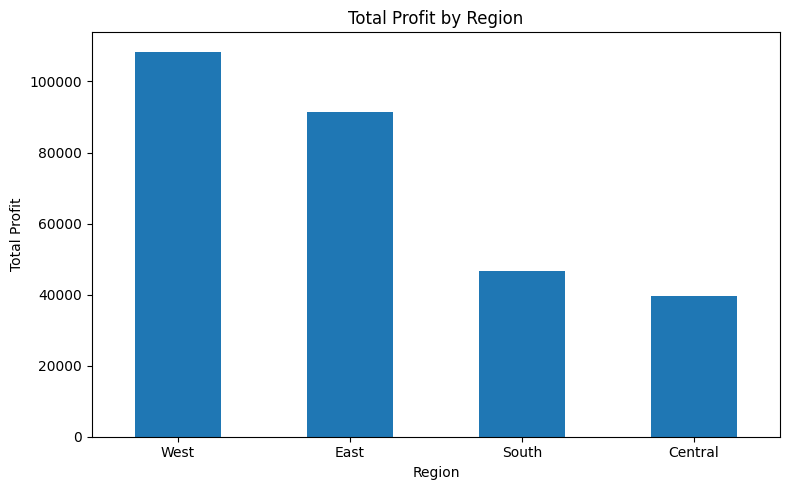

In [20]:
#Region vs Profit
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/profit.png',bbox_inches='tight', dpi=100)
plt.show()

In [21]:
files.download('/content/profit.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###### Plot2

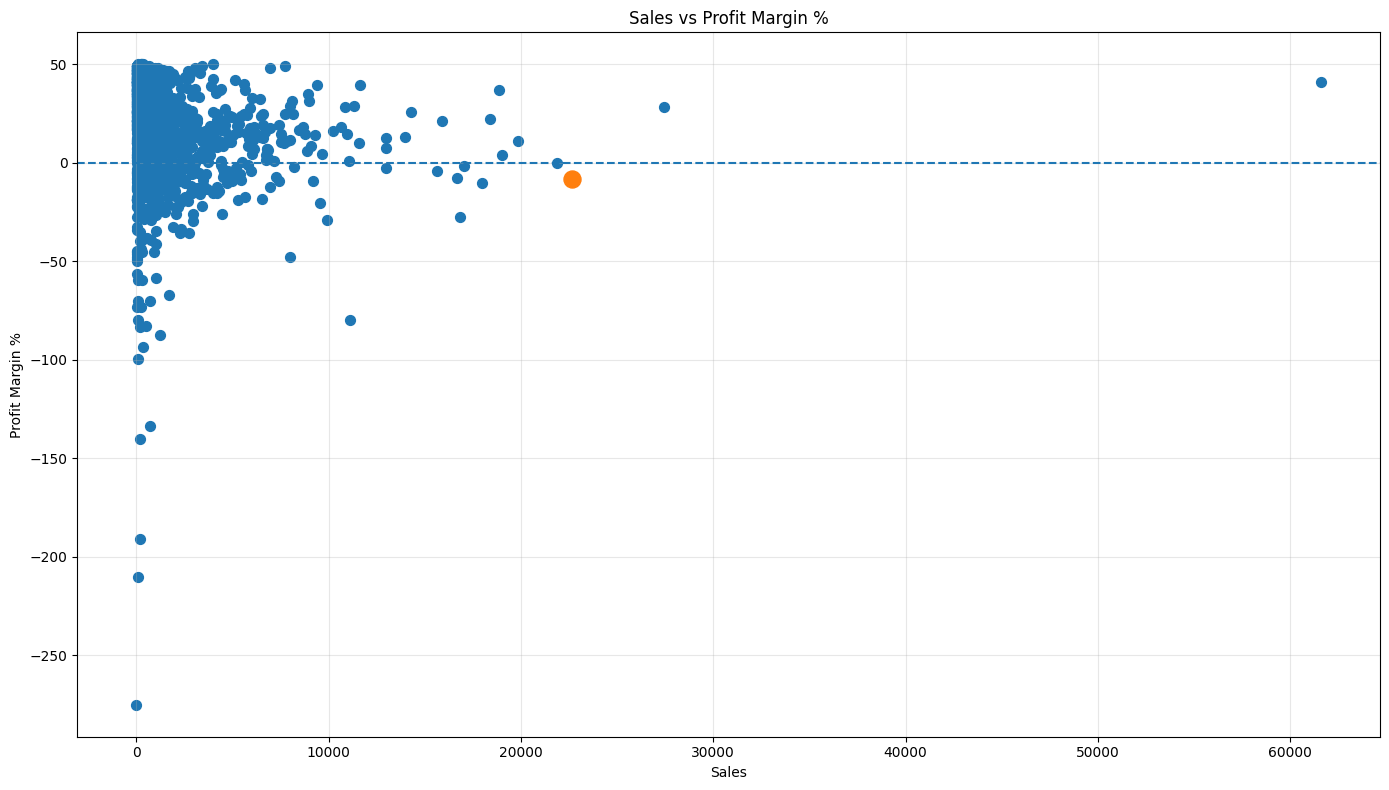

In [22]:
plt.figure(figsize=(14, 8))
plt.scatter(product['Sales'], product['Profit Margin %'], s=50)
cisco = product.loc['Cisco TelePresence System EX90 Videoconferencing Unit']
plt.scatter(cisco['Sales'], cisco['Profit Margin %'], s=150)
plt.axhline(0, linestyle='--')
plt.xlabel('Sales')
plt.ylabel('Profit Margin %')
plt.title('Sales vs Profit Margin %')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/mystery_sales_profit_margin vs profit.png',bbox_inches='tight', dpi=300)
plt.show()

In [23]:
files.download('/content/mystery_sales_profit_margin vs profit.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Business Recomendation

1. Focus on highly profitable products and categories,especially Technology and products like the Canon imageCLASS 2200 Advanced Copier,by maintaining inventory and increasing targeted promotion.

2. Strengthen the West region strategy since it has the highest total profit, while investigating other regions to identify why their profitability is lower and what can be improved.

3. Review pricing and discounts for high sales,low profit products such as the Cisco TelePresence System EX90 to reduce losses and improve profit margins.

# Mystery
The Cisco TelePresence System EX90 looked successful because of its high sales, but it wasn't profitable because it had a negative profit margin.